<a href="https://colab.research.google.com/github/amruta-katkar/google-play-analysis/blob/main/DSVProjectA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google playstore Data Analysis

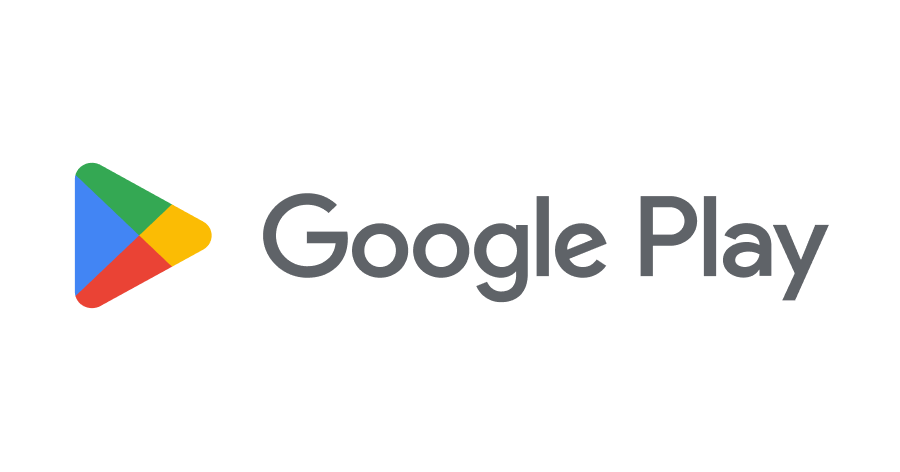

# About Dataset

**Context**
Google PlayStore Android App Data. (2.3 Million+ App Data)
Backup repo: https://github.com/gauthamp10/Google-Playstore-Dataset

**Content**
I've collected the data with the help of Python script (Scrapy) running on a cloud vm instance.
The data was collected in the month of June 2021.

**Inspiration**
Took inspiration from: https://www.kaggle.com/lava18/google-play-store-apps to build a big database for students and researchers.

Website: gauthamp10.github.io


**About this file**
This files contains Application data of more than 600K applications with the following 23 attributes.-

1. App Name
2. App Id
3. Category
4. Rating
5. Rating Count
6. Installs
7. Minimum Installs
8. Maximum Installs
9. Free
10. Price
11. Currency
12. Size
13. Minimum Android
14. Developer Id
15. Developer Website
16. Developer Email
17. Released
18. Privacy Policy
19. Last Updated
20. Content Rating
21. Ad Supported
22. In app purchases
23. Editor Choice




In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gauthamp10/google-playstore-apps")

print("Path to dataset files:", path)

100%|██████████| 207M/207M [00:02<00:00, 102MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gauthamp10/google-playstore-apps/versions/7


1.Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2.Data Loading and Exploration | Cleaning

In [ ]:
import pandas as pd

dataset_path = "/root/.cache/kagglehub/datasets/gauthamp10/google-playstore-apps/versions/7/Google-Playstore.csv"

df = pd.read_csv(dataset_path)


In [ ]:
# df=pd.read_csv("/content/googleplaystore.csv")

In [ ]:
# dataset=df.to_csv("Google-Playstore.csv", index=False)

In [ ]:
df.head(5)

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


In [ ]:
# for hide warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df.columns

Index(['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency',
       'Size', 'Minimum Android', 'Developer Id', 'Developer Website',
       'Developer Email', 'Released', 'Last Updated', 'Content Rating',
       'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Scraped Time'],
      dtype='object')

In [ ]:
df.shape

(2312944, 24)

In [ ]:
print(f"rows: {df.shape[0]}")
print(f"columns: {df.shape[1]}")

rows: 2312944
columns: 24


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           object 
 1   App Id             object 
 2   Category           object 
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           object 
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           object 
 11  Size               object 
 12  Minimum Android    object 
 13  Developer Id       object 
 14  Developer Website  object 
 15  Developer Email    object 
 16  Released           object 
 17  Last Updated       object 
 18  Content Rating     object 
 19  Privacy Policy     object 
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
 23  Scraped Time       object 
dtypes: bool(4), float64(4), int64(1), object(15)
memor

In [ ]:
df.describe()

,Rating,Rating Count,Minimum Installs,Maximum Installs,Price
count,2.290061e+06,2.290061e+06,2.312837e+06,2.312944e+06,2.312944e+06
mean,2.203152e+00,2.864839e+03,1.834452e+05,3.202017e+05,1.034992e-01
std,2.106223e+00,2.121626e+05,1.513144e+07,2.355495e+07,2.633127e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,5.000000e+01,8.400000e+01,0.000000e+00
50%,2.900000e+00,6.000000e+00,5.000000e+02,6.950000e+02,0.000000e+00
75%,4.300000e+00,4.200000e+01,5.000000e+03,7.354000e+03,0.000000e+00
max,5.000000e+00,1.385576e+08,1.000000e+10,1.205763e+10,4.000000e+02


#**Project Name - Google playstore App Analysis**#

**NAME : AMRUTA KATKAR**

**NAME : RUTUJA PATIL**

**NAME : SAJIDA MUJAWAR**

**NAME : SIDDHI POTDAR**

# App Name contains duplicates and various language name remove those records

In [ ]:
df['App Name'].value_counts()

,count
App Name,
Tic Tac Toe,382
Calculator,261
Flashlight,256
BMI Calculator,201
Age Calculator,190
...,...
SK Backup Tool,1
Pokémon Pass,1
Face Shattering Effect,1


In [ ]:
df["App Name"].unique()

array(['Gakondo', 'Ampere Battery Info', 'Vibook', ..., '大俠客—熱血歸來',
       'ORU Online', 'Biliyor Musun - Sonsuz Yarış'], dtype=object)

In [ ]:
df["App Name"].duplicated().sum()

np.int64(135000)

In [ ]:
df.drop_duplicates(subset="App Name", keep="first", inplace=True)

In [ ]:
import re

# Function to check if the app name is in English
def is_english(name):
    return bool(re.match(r'^[A-Za-z0-9\s\-\_\!\.\,\&\(\)\']+$', str(name)))

# Keep only rows where the app name is English
df = df[df["App Name"].apply(is_english)]

# Reset index after filtering
df.reset_index(drop=True, inplace=True)

print("Filtered DataFrame contains only English app names.")

Filtered DataFrame contains only English app names.


In [ ]:
# let's check the null values again
df.isnull().sum().sort_values(ascending=False)

,0
Developer Website,555591
Privacy Policy,314608
Released,53313
Rating,18543
Rating Count,18543
Minimum Android,5170
Size,146
Currency,101
Minimum Installs,78
Installs,78


# drop null values from dataframe

In [ ]:
df = df.dropna(subset=["App Name", "Developer Email", "Developer Id"])

# Rating contain 18543 null values so fill with mean()

In [ ]:
df["Rating"].fillna(df["Rating"].mean(), inplace=True)
df["Rating Count"].fillna(0, inplace=True)

# Installs and Minimum Installs contain 78 null values filled with median

In [ ]:
df["Installs"].fillna(df["Minimum Installs"].median(), inplace=True)
df["Minimum Installs"].fillna(df["Minimum Installs"].median(), inplace=True)

In [ ]:
df["Size"].fillna("Unknown", inplace=True)

In [ ]:
df["Minimum Android"].fillna("Varies with device", inplace=True)

In [ ]:
df["Released"].fillna("Unknown", inplace=True)

In [ ]:
df["Developer Website"].fillna("Not Available", inplace=True)
df["Privacy Policy"].fillna("Not Provided", inplace=True)

In [ ]:
df["Currency"].fillna("USD", inplace=True)

In [ ]:
print(df.isnull().sum())  # Check if all missing values are handled

App Name             0
App Id               0
Category             0
Rating               0
Rating Count         0
Installs             0
Minimum Installs     0
Maximum Installs     0
Free                 0
Price                0
Currency             0
Size                 0
Minimum Android      0
Developer Id         0
Developer Website    0
Developer Email      0
Released             0
Last Updated         0
Content Rating       0
Privacy Policy       0
Ad Supported         0
In App Purchases     0
Editors Choice       0
Scraped Time         0
dtype: int64


In [ ]:
df["Installs"].unique()

array(['10+', '5,000+', '50+', '100+', '1,000+', '500+', '50,000+',
       '10,000+', '1+', '500,000+', '100,000+', '5+', '1,000,000+',
       '5,000,000+', '10,000,000+', '0+', '100,000,000+', '50,000,000+',
       '1,000,000,000+', '500,000,000+', 500.0, '5,000,000,000+',
       '10,000,000,000+'], dtype=object)

In [ ]:
df['Installs'].value_counts()

,count
Installs,
100+,348922
"1,000+",292305
10+,245309
"10,000+",175704
500+,144024
50+,137376
"5,000+",101458
"100,000+",72545
5+,61479


# taking care of Installs column

In [ ]:
df['Installs'] = df['Installs'].apply(lambda x: x.replace('+',"") if '+' in str(x) else x)

In [ ]:
df['Installs'] = df['Installs'].apply(lambda x: x.replace(',',"") if ',' in str(x) else x)

In [ ]:
df["Installs"] = df["Installs"].astype(int)

In [ ]:
pd.set_option('display.max_rows', None)  # Show all rows
print(df['Size'].unique())  # Display all unique values


['10M' '2.9M' '3.7M' ... '512M' '405M' '1.0G']


# taking care of Size column

In [ ]:
df["Size"].value_counts()

,count
Size,
Varies with device,57148
11M,47795
12M,43456
13M,36327
14M,34037
16M,32856
15M,31827
17M,29342
10M,25914


In [ ]:
import numpy as np

def convert_size(size):
    size = str(size).lower().strip().replace(",", "")  # Normalize text

    # Fix common typos
    if size in ["unnown", "unkown", "unknown", "varies with device"]:
        return np.nan  # Set unknown sizes to NaN

    if "m" in size:  # Convert MB to KB
        try:
            return float(size.replace("m", "")) * 1024
        except ValueError:
            return np.nan
    elif "k" in size:  # Convert KB to numeric
        try:
            return float(size.replace("k", ""))
        except ValueError:
            return np.nan
    else:
        return np.nan  # Any unexpected format is set to NaN

df["Size"] = df["Size"].apply(convert_size)
df["Size"].fillna(df["Size"].median(), inplace=True)  # Fill NaN with median
df["Size"] = df["Size"].astype(int)  # Convert to integer


In [ ]:
print(df["Size"].unique())  # Should only contain numbers
print(df["Size"].describe())  # Check min, max, mean

[ 10240   2969   3788 ... 520192 524288 414720]
count    1.743574e+06
mean     1.962721e+04
std      2.403893e+04
min      3.000000e+00
25%      5.324000e+03
50%      1.126400e+04
75%      2.560000e+04
max      1.044480e+06
Name: Size, dtype: float64


# taking care of Price column

In [ ]:
df['Price'].value_counts()

,count
Price,
0.000000,1709678
0.990000,9221
1.990000,4549
1.490000,2864
2.990000,2860
4.990000,1888
3.990000,1857
2.490000,1625
3.490000,953


In [ ]:
#convert into numeric value
df['Price'] = df['Price'].apply(lambda x: float(x))

In [ ]:
# using f string print min, max and average prices of the app
print(f"min price: {df['Price'].min()}")
print(f"max price: {df['Price'].max()}")
print(f"average price: {df['Price'].mean()}")

min price: 0.0
max price: 400.0
average price: 0.10267249952396623


# convert Released & Last Upadated column to date format

In [ ]:
df["Released"] = pd.to_datetime(df["Released"], errors="coerce")
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

# converting "Free", "Ad Supported", "In App Purchases", "Editors Choice" to boolean

In [ ]:
bool_cols = ["Free", "Ad Supported", "In App Purchases", "Editors Choice"]
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
print(df.dtypes)

App Name                     object
App Id                       object
Category                     object
Rating                      float64
Rating Count                float64
Installs                      int64
Minimum Installs            float64
Maximum Installs              int64
Free                          int64
Price                       float64
Currency                     object
Size                          int64
Minimum Android              object
Developer Id                 object
Developer Website            object
Developer Email              object
Released             datetime64[ns]
Last Updated         datetime64[ns]
Content Rating               object
Privacy Policy               object
Ad Supported                  int64
In App Purchases              int64
Editors Choice                int64
Scraped Time                 object
dtype: object


# taking care of Currency column

In [ ]:
df["Currency"].unique()

array(['USD', 'XXX', 'CAD', 'EUR', 'INR', 'VND', 'BRL', 'TRY', 'GBP',
       'SGD', 'AUD', 'PKR', 'ZAR'], dtype=object)

# converting price into Indian ruppees

In [ ]:
exchange_rates_to_inr = {
    "USD": 83, "CAD": 62, "EUR": 91, "INR": 1, "VND": 0.0035,
    "GBP": 106, "BRL": 16.5, "KRW": 0.063, "TRY": 2.7, "RUB": 0.91,
    "SGD": 61, "AUD": 55, "PKR": 0.3, "ZAR": 4.3 ,"XXX": 0
}

def convert_to_inr(df):
    return df["Price"] * exchange_rates_to_inr.get(df["Currency"], 1)  # Convert price

df["Price_INR"] = df.apply(convert_to_inr, axis=1)  # Apply conversion


In [ ]:
df.drop(columns=["Currency", "Price"], inplace=True)  # Drop old columns


In [ ]:
df["Price_INR"].value_counts()

,count
Price_INR,
0.000000,1709678
82.170000,9221
165.170000,4549
123.670000,2864
248.170000,2860
414.170000,1888
331.170000,1857
206.670000,1625
289.670000,953


In [ ]:
print(df["Price_INR"].describe())  # Check price distribution
print(df[["Price_INR"]].head())  # Verify conversion

count    1.743574e+06
mean     8.521817e+00
std      2.174676e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.320000e+04
Name: Price_INR, dtype: float64
   Price_INR
0        0.0
1        0.0
2        0.0
3        0.0
4        0.0


In [ ]:
df["Price_INR"].unique()

array([0.00000000e+00, 1.65170000e+02, 4.14170000e+02, 8.21700000e+01,
       2.89670000e+02, 2.07417000e+03, 3.72670000e+02, 2.48170000e+02,
       8.29917000e+03, 1.23670000e+02, 2.06670000e+02, 3.31170000e+02,
       4.55670000e+02, 3.48517000e+03, 5.38670000e+02, 4.39070000e+02,
       1.65917000e+03, 8.29170000e+02, 3.31917000e+03, 7.46170000e+02,
       2.40617000e+03, 6.63170000e+02, 6.05485000e+03, 4.06285000e+03,
       3.04610000e+02, 4.40730000e+02, 5.80170000e+02, 1.16117000e+03,
       8.88100000e+01, 9.95170000e+02, 4.97170000e+02, 9.12170000e+02,
       2.55640000e+02, 2.48585000e+03, 5.47717000e+03, 8.30000000e+01,
       4.91360000e+02, 2.98717000e+03, 2.73817000e+03, 4.15000000e+02,
       6.21670000e+02, 7.87670000e+02, 1.75130000e+02, 3.31991700e+04,
       8.71500000e+01, 3.65117000e+03, 2.86350000e+02, 7.04670000e+02,
       1.24417000e+03, 1.07817000e+03, 2.24017000e+03, 1.99117000e+03,
       4.52636765e+02, 9.18810000e+02, 5.39417000e+03, 2.03018000e+03,
      

In [ ]:
print(df.dtypes)

App Name                     object
App Id                       object
Category                     object
Rating                      float64
Rating Count                float64
Installs                      int64
Minimum Installs            float64
Maximum Installs              int64
Free                          int64
Size                          int64
Minimum Android              object
Developer Id                 object
Developer Website            object
Developer Email              object
Released             datetime64[ns]
Last Updated         datetime64[ns]
Content Rating               object
Privacy Policy               object
Ad Supported                  int64
In App Purchases              int64
Editors Choice                int64
Scraped Time                 object
Price_INR                   float64
dtype: object


# Taking care of outliers

In [ ]:
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)  # 25th percentile
    Q3 = df[column].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Check outliers in key columns
outlier_cols = ["Rating", "Rating Count", "Installs", "Price_INR", "Size"]
for col in outlier_cols:
    print(f"\n🔍 Outliers in {col}: {len(detect_outliers(col))}")


🔍 Outliers in Rating: 0

🔍 Outliers in Rating Count: 295328

🔍 Outliers in Installs: 171563

🔍 Outliers in Price_INR: 33896

🔍 Outliers in Size: 119786


In [ ]:
df["Price_INR"].unique()

array([0.00000000e+00, 1.65170000e+02, 4.14170000e+02, 8.21700000e+01,
       2.89670000e+02, 2.07417000e+03, 3.72670000e+02, 2.48170000e+02,
       8.29917000e+03, 1.23670000e+02, 2.06670000e+02, 3.31170000e+02,
       4.55670000e+02, 3.48517000e+03, 5.38670000e+02, 4.39070000e+02,
       1.65917000e+03, 8.29170000e+02, 3.31917000e+03, 7.46170000e+02,
       2.40617000e+03, 6.63170000e+02, 6.05485000e+03, 4.06285000e+03,
       3.04610000e+02, 4.40730000e+02, 5.80170000e+02, 1.16117000e+03,
       8.88100000e+01, 9.95170000e+02, 4.97170000e+02, 9.12170000e+02,
       2.55640000e+02, 2.48585000e+03, 5.47717000e+03, 8.30000000e+01,
       4.91360000e+02, 2.98717000e+03, 2.73817000e+03, 4.15000000e+02,
       6.21670000e+02, 7.87670000e+02, 1.75130000e+02, 3.31991700e+04,
       8.71500000e+01, 3.65117000e+03, 2.86350000e+02, 7.04670000e+02,
       1.24417000e+03, 1.07817000e+03, 2.24017000e+03, 1.99117000e+03,
       4.52636765e+02, 9.18810000e+02, 5.39417000e+03, 2.03018000e+03,
      

In [ ]:
outlier_cols = ["Rating Count", "Installs", "Size"]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower_bound, upper_bound)  # Capping outliers


In [ ]:
df["Price_INR"].unique()

array([0.00000000e+00, 1.65170000e+02, 4.14170000e+02, 8.21700000e+01,
       2.89670000e+02, 2.07417000e+03, 3.72670000e+02, 2.48170000e+02,
       8.29917000e+03, 1.23670000e+02, 2.06670000e+02, 3.31170000e+02,
       4.55670000e+02, 3.48517000e+03, 5.38670000e+02, 4.39070000e+02,
       1.65917000e+03, 8.29170000e+02, 3.31917000e+03, 7.46170000e+02,
       2.40617000e+03, 6.63170000e+02, 6.05485000e+03, 4.06285000e+03,
       3.04610000e+02, 4.40730000e+02, 5.80170000e+02, 1.16117000e+03,
       8.88100000e+01, 9.95170000e+02, 4.97170000e+02, 9.12170000e+02,
       2.55640000e+02, 2.48585000e+03, 5.47717000e+03, 8.30000000e+01,
       4.91360000e+02, 2.98717000e+03, 2.73817000e+03, 4.15000000e+02,
       6.21670000e+02, 7.87670000e+02, 1.75130000e+02, 3.31991700e+04,
       8.71500000e+01, 3.65117000e+03, 2.86350000e+02, 7.04670000e+02,
       1.24417000e+03, 1.07817000e+03, 2.24017000e+03, 1.99117000e+03,
       4.52636765e+02, 9.18810000e+02, 5.39417000e+03, 2.03018000e+03,
      

In [ ]:
for col in outlier_cols:
    print(f"\n📊 {col} after outlier handling:\n", df[col].describe())



📊 Rating Count after outlier handling:
 count    1.743574e+06
mean     2.168512e+01
std      3.134864e+01
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+00
75%      3.300000e+01
max      8.250000e+01
Name: Rating Count, dtype: float64

📊 Installs after outlier handling:
 count    1.743574e+06
mean     2.755795e+03
std      4.395309e+03
min      0.000000e+00
25%      5.000000e+01
50%      5.000000e+02
75%      5.000000e+03
max      1.242500e+04
Name: Installs, dtype: float64

📊 Size after outlier handling:
 count    1.743574e+06
mean     1.751982e+04
std      1.631280e+04
min      3.000000e+00
25%      5.324000e+03
50%      1.126400e+04
75%      2.560000e+04
max      5.601400e+04
Name: Size, dtype: float64


In [ ]:
print(f"rows: {df.shape[0]}")
print(f"columns: {df.shape[1]}")

rows: 1743574
columns: 23


In [ ]:
df.columns

Index(['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs',
       'Minimum Installs', 'Maximum Installs', 'Free', 'Size',
       'Minimum Android', 'Developer Id', 'Developer Website',
       'Developer Email', 'Released', 'Last Updated', 'Content Rating',
       'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice',
       'Scraped Time', 'Price_INR'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743574 entries, 0 to 1743622
Data columns (total 23 columns):
 #   Column             Dtype         
---  ------             -----         
 0   App Name           object        
 1   App Id             object        
 2   Category           object        
 3   Rating             float64       
 4   Rating Count       float64       
 5   Installs           int64         
 6   Minimum Installs   float64       
 7   Maximum Installs   int64         
 8   Free               int64         
 9   Size               int64         
 10  Minimum Android    object        
 11  Developer Id       object        
 12  Developer Website  object        
 13  Developer Email    object        
 14  Released           datetime64[ns]
 15  Last Updated       datetime64[ns]
 16  Content Rating     object        
 17  Privacy Policy     object        
 18  Ad Supported       int64         
 19  In App Purchases   int64         
 20  Editors Choice     int64     

In [ ]:
df.describe()

,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Size,Released,Last Updated,Ad Supported,In App Purchases,Editors Choice,Price_INR
count,1.743574e+06,1.743574e+06,1.743574e+06,1.743574e+06,1.743574e+06,1.743574e+06,1.743574e+06,1690264,1743574,1.743574e+06,1.743574e+06,1.743574e+06,1.743574e+06
mean,2.097604e+00,2.168512e+01,2.755795e+03,1.720077e+05,3.031716e+05,9.805015e-01,1.751982e+04,2018-08-30 14:12:40.184207616,2019-12-03 01:42:45.581273088,4.603005e-01,7.887764e-02,2.569435e-04,8.521817e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,2010-01-28 00:00:00,2009-02-11 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,5.000000e+01,5.000000e+01,6.900000e+01,1.000000e+00,5.324000e+03,2017-06-30 00:00:00,2019-04-11 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.097604e+00,5.000000e+00,5.000000e+02,5.000000e+02,5.300000e+02,1.000000e+00,1.126400e+04,2019-03-22 00:00:00,2020-05-14 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.200000e+00,3.300000e+01,5.000000e+03,5.000000e+03,5.419000e+03,1.000000e+00,2.560000e+04,2020-04-21 00:00:00,2021-02-07 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,5.000000e+00,8.250000e+01,1.242500e+04,1.000000e+10,1.205763e+10,1.000000e+00,5.601400e+04,2021-06-15 00:00:00,2021-06-16 00:00:00,1.000000e+00,1.000000e+00,1.000000e+00,3.320000e+04
std,2.093781e+00,3.134864e+01,4.395309e+03,1.619951e+07,2.543300e+07,1.382689e-01,1.631280e+04,NaN,NaN,4.984216e-01,2.695478e-01,1.602740e-02,2.174676e+02


In [ ]:
# category with highest number of Installs
df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

,Installs
Category,
Education,407580118
Tools,382293675
Entertainment,366267250
Personalization,281458082
Music & Audio,261817279
Books & Reference,236639265
Lifestyle,196155282
Finance,168653903
Business,157287179


In [ ]:
# Category with highest number of Reviews
df.groupby('Category')["Rating Count"].sum().sort_values(ascending=False).head(10)

,Rating Count
Category,
Education,3552106.5
Tools,2922157.5
Entertainment,2661658.0
Personalization,2134835.0
Music & Audio,2120062.0
Books & Reference,1719569.0
Lifestyle,1501894.5
Finance,1430043.5
Business,1336464.5


In [ ]:
# Category with highest average Rating
df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

,Rating
Category,
Role Playing,3.247349
Casino,3.192004
Simulation,3.110174
Weather,3.035492
Card,2.930114
Racing,2.890195
Video Players & Editors,2.864553
Comics,2.784634
Personalization,2.771214


In [ ]:
df.drop(columns=["Minimum Installs"], inplace=True)

In [ ]:
df["In App Purchases"].unique()

array([0, 1])

In [ ]:
df.drop(columns=["Free"], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743574 entries, 0 to 1743622
Data columns (total 21 columns):
 #   Column             Dtype         
---  ------             -----         
 0   App Name           object        
 1   App Id             object        
 2   Category           object        
 3   Rating             float64       
 4   Rating Count       float64       
 5   Installs           int64         
 6   Maximum Installs   int64         
 7   Size               int64         
 8   Minimum Android    object        
 9   Developer Id       object        
 10  Developer Website  object        
 11  Developer Email    object        
 12  Released           datetime64[ns]
 13  Last Updated       datetime64[ns]
 14  Content Rating     object        
 15  Privacy Policy     object        
 16  Ad Supported       int64         
 17  In App Purchases   int64         
 18  Editors Choice     int64         
 19  Scraped Time       object        
 20  Price_INR          float64   

In [ ]:
df["Minimum Android"].unique()

array(['7.1 and up', '5.0 and up', '4.0.3 and up', '4.1 and up',
       '6.0 and up', '4.4 and up', '4.0 and up', '4.2 and up',
       '7.0 and up', '2.2 and up', '2.1 and up', '2.3 and up',
       '4.3 and up', '5.1 and up', 'Varies with device', '1.6 and up',
       '3.0 and up', '8.0 and up', '2.3.3 and up', '4.4W and up',
       '3.2 and up', '1.5 and up', '4.0.3 - 7.1.1', '3.1 and up',
       '2.0 and up', '1.0 and up', '1.1 and up', '2.0.1 and up',
       '4.4 - 6.0', '2.1 - 4.4', '4.0 - 5.0', '2.0 - 2.3.4', '4.1 - 7.0',
       '4.1 - 6.0', '4.0 - 4.4W', '4.0 - 4.4', '2.3 - 5.0', '4.0 - 7.1.1',
       '4.0 - 7.0', '4.1 - 8.0', '4.0 - 6.0', '4.0 - 8.0', '2.3 - 6.0',
       '2.1 - 2.3.4', '3.0 - 4.1.1', '4.1 - 7.1.1', '2.2 - 3.0',
       '2.0 - 8.0', '4.0.3 - 8.0', '3.0 - 4.4W', '4.0.3 - 7.0',
       '4.4 - 7.1.1', '4.4 - 8.0', '1.6 - 4.0.4', '8.0', '2.3 - 5.1',
       '2.1 - 7.1.1', '2.3 - 4.4W', '4.4 - 7.0', '2.3 - 4.4',
       '2.2 - 4.0.4', '2.1 - 4.1.1', '3.0 - 8.0', '3.0 - 5.

In [ ]:
df["Content Rating"].unique()

array(['Everyone', 'Teen', 'Mature 17+', 'Everyone 10+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [ ]:
df["Privacy Policy"].unique()

array(['https://beniyizibyose.tk/projects/',
       'https://dev4phones.wordpress.com/licencia-de-uso/',
       'https://www.vietnamairlines.com/vn/en/terms-and-conditions/privacy-policy',
       ..., 'https://www.gokarli.de/Datenschutz',
       'https://docs.google.com/document/d/1I310VsRWy8deAgHokvshyN8fy1syHPVPMM2ptTGfB8w/edit?usp=sharing',
       'http://www.oru.edu/about-oru/privacy-policy.php'], dtype=object)

In [ ]:
df["Ad Supported"].unique()

array([0, 1])

In [ ]:
df["Editors Choice"].unique()

array([0, 1])

In [ ]:
df["Scraped Time"].unique()

array(['2021-06-15 20:19:35', '2021-06-15 20:19:36',
       '2021-06-15 20:19:37', ..., '2021-06-16 12:30:53',
       '2021-06-16 12:30:54', '2021-06-16 12:30:55'], dtype=object)

# Privacy Policy & Scraped Time column deleted

In [ ]:
df.drop(columns=["Privacy Policy", "Scraped Time"], inplace=True)

In [ ]:
df.describe()

,Rating,Rating Count,Installs,Maximum Installs,Size,Released,Last Updated,Ad Supported,In App Purchases,Editors Choice,Price_INR
count,1.743574e+06,1.743574e+06,1.743574e+06,1.743574e+06,1.743574e+06,1690264,1743574,1.743574e+06,1.743574e+06,1.743574e+06,1.743574e+06
mean,2.097604e+00,2.168512e+01,2.755795e+03,3.031716e+05,1.751982e+04,2018-08-30 14:12:40.184207616,2019-12-03 01:42:45.581273088,4.603005e-01,7.887764e-02,2.569435e-04,8.521817e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,2010-01-28 00:00:00,2009-02-11 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,5.000000e+01,6.900000e+01,5.324000e+03,2017-06-30 00:00:00,2019-04-11 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.097604e+00,5.000000e+00,5.000000e+02,5.300000e+02,1.126400e+04,2019-03-22 00:00:00,2020-05-14 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.200000e+00,3.300000e+01,5.000000e+03,5.419000e+03,2.560000e+04,2020-04-21 00:00:00,2021-02-07 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,5.000000e+00,8.250000e+01,1.242500e+04,1.205763e+10,5.601400e+04,2021-06-15 00:00:00,2021-06-16 00:00:00,1.000000e+00,1.000000e+00,1.000000e+00,3.320000e+04
std,2.093781e+00,3.134864e+01,4.395309e+03,2.543300e+07,1.631280e+04,NaN,NaN,4.984216e-01,2.695478e-01,1.602740e-02,2.174676e+02


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743574 entries, 0 to 1743622
Data columns (total 19 columns):
 #   Column             Dtype         
---  ------             -----         
 0   App Name           object        
 1   App Id             object        
 2   Category           object        
 3   Rating             float64       
 4   Rating Count       float64       
 5   Installs           int64         
 6   Maximum Installs   int64         
 7   Size               int64         
 8   Minimum Android    object        
 9   Developer Id       object        
 10  Developer Website  object        
 11  Developer Email    object        
 12  Released           datetime64[ns]
 13  Last Updated       datetime64[ns]
 14  Content Rating     object        
 15  Ad Supported       int64         
 16  In App Purchases   int64         
 17  Editors Choice     int64         
 18  Price_INR          float64       
dtypes: datetime64[ns](2), float64(3), int64(6), object(8)
memory usage: 

# BARPLOT on Top 5 Rated Paid Apps

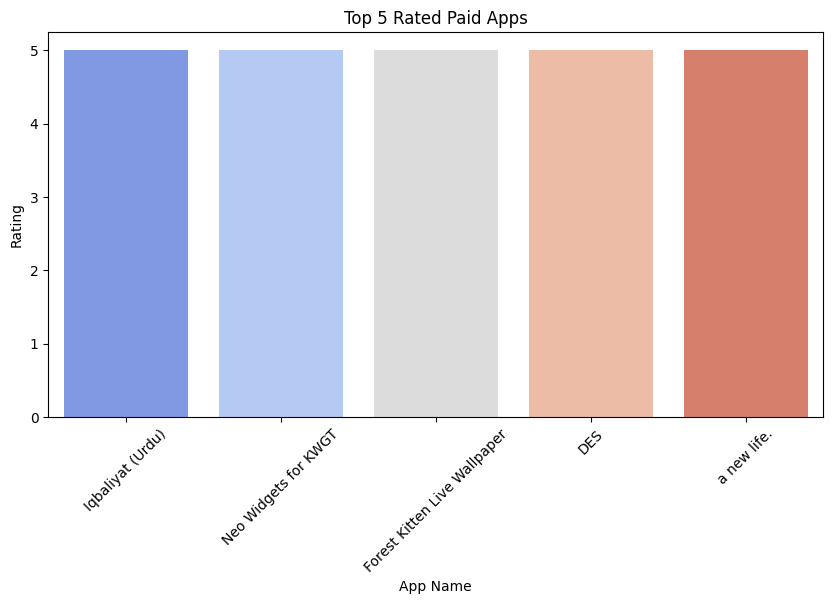

In [ ]:
# --- Top 5 Rated Paid Apps ---
paid_apps = df[df['Price_INR'] > 0]
top_rated_paid = paid_apps.nlargest(5, 'Rating')
plt.figure(figsize=(10, 5))
sns.barplot(x=top_rated_paid['App Name'], y=top_rated_paid['Rating'], palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Top 5 Rated Paid Apps")
plt.xlabel("App Name")
plt.ylabel("Rating")
plt.show()

In [ ]:
# --- Count of Apps in 'Everyone' Content Rating ---
everyone_apps = df[df['Content Rating'] == 'Everyone']
print(f"Number of apps with 'Everyone' content rating: {len(everyone_apps)}")

Number of apps with 'Everyone' content rating: 1532760


# Most Popular Content Rating by Installs : barplot

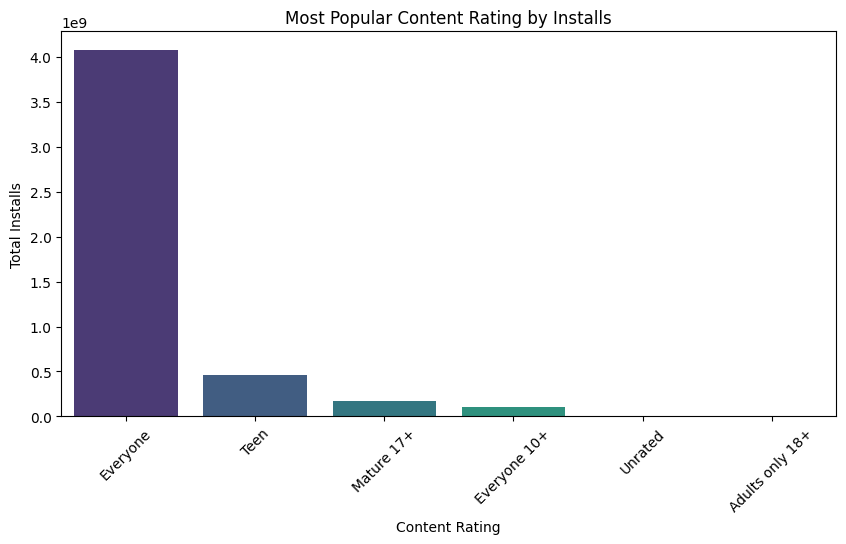

In [ ]:
# --- Most Popular Content Rating by Installs ---
content_rating_installs = df.groupby('Content Rating')['Installs'].sum().reset_index()
content_rating_installs = content_rating_installs.sort_values(by='Installs', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=content_rating_installs['Content Rating'], y=content_rating_installs['Installs'], palette='viridis')
plt.xticks(rotation=45)
plt.title("Most Popular Content Rating by Installs")
plt.xlabel("Content Rating")
plt.ylabel("Total Installs")
plt.show()

# Scatter Plot: Installs vs Price (Hue by Paid/Free Type)bold text

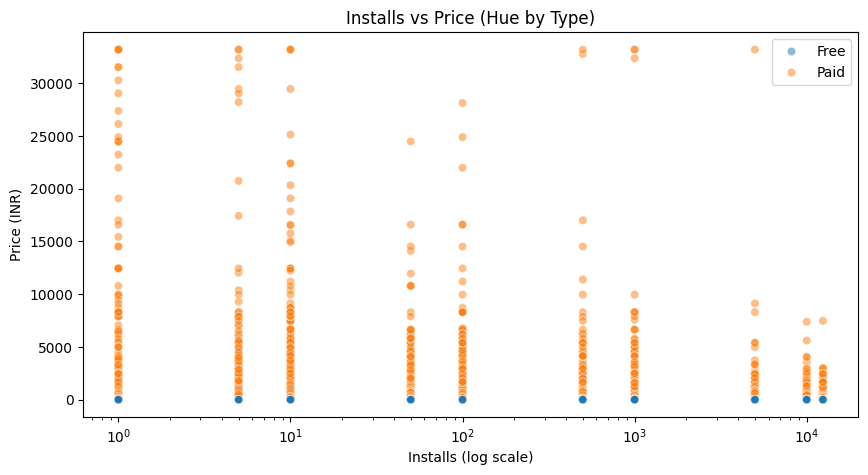

In [ ]:
# --- Scatter Plot: Installs vs Price (Hue by Paid/Free Type) ---
df['Type'] = df['Price_INR'].apply(lambda x: 'Paid' if x > 0 else 'Free')
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Installs', y='Price_INR', hue='Type', alpha=0.5)
plt.xscale('log')  # Using log scale for better visualization
plt.title("Installs vs Price (Hue by Type)")
plt.xlabel("Installs (log scale)")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

In [ ]:
df['Price_INR'].min()

0.0

# 5 free app with highest reviews

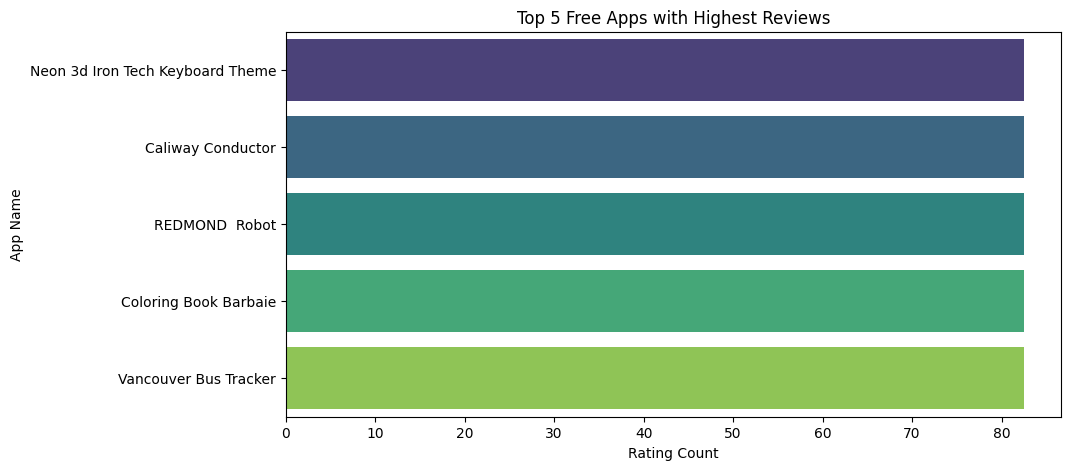

In [ ]:
# 5 free app with highest reviews
top_free_reviews = df[df['Price_INR'] == 0].nlargest(5, 'Rating Count')
plt.figure(figsize=(10,5))
sns.barplot(x='Rating Count', y='App Name', data=top_free_reviews, palette='viridis')
plt.title('Top 5 Free Apps with Highest Reviews')
plt.show()


# Number of Apps per Category : Countplot

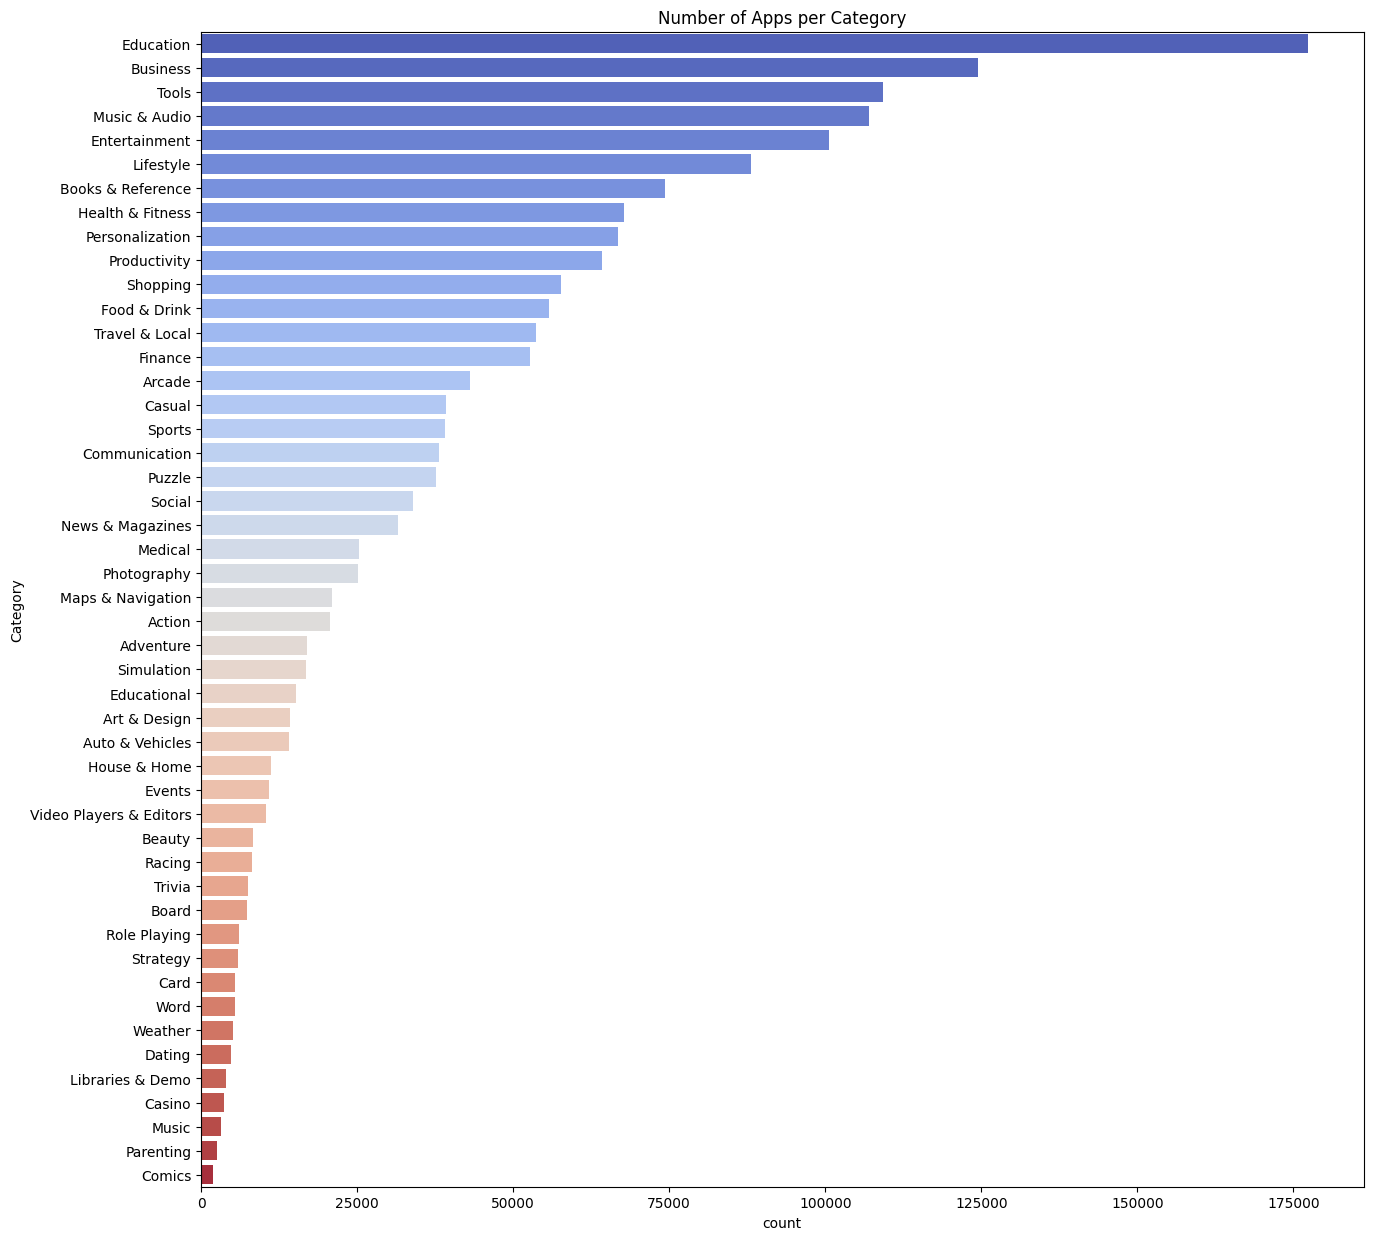

In [ ]:
plt.figure(figsize=(15,15))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='coolwarm')
plt.title('Number of Apps per Category')
plt.show()


Distribution of App Ratings : Histogram plot

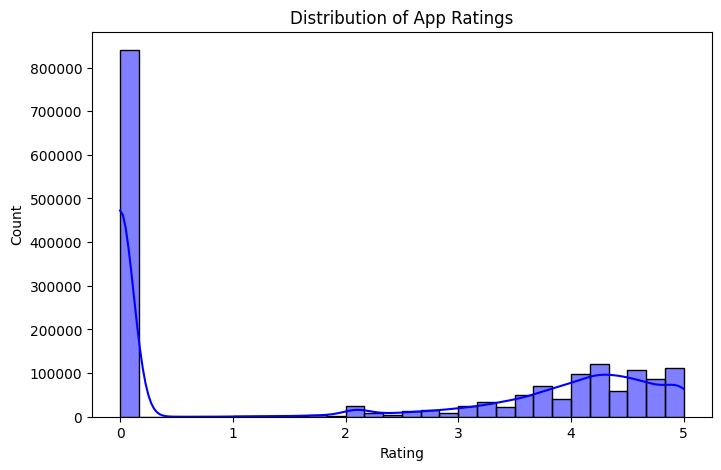

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=30, kde=True, color='blue')
plt.title('Distribution of App Ratings')
plt.show()


# Top 10 Most Installed Apps

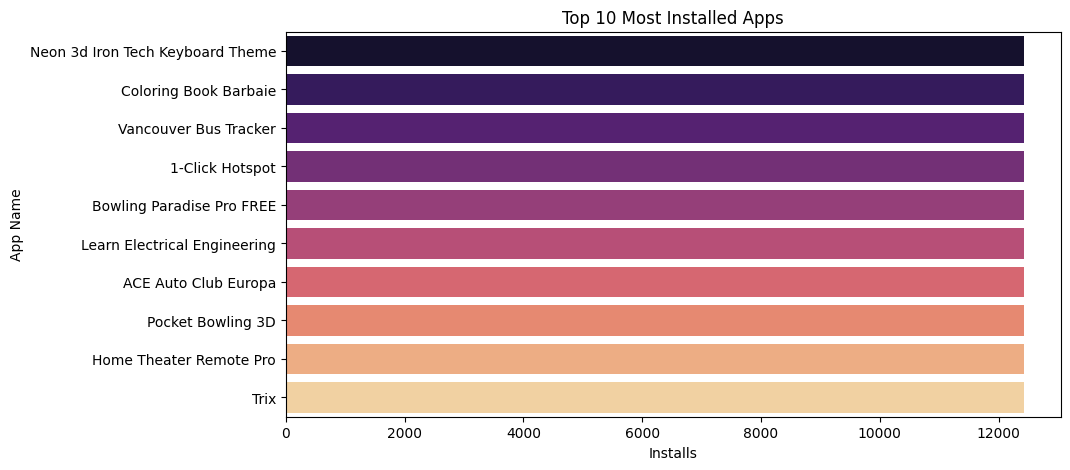

In [ ]:
top_installed_apps = df.nlargest(10, 'Installs')
plt.figure(figsize=(10,5))
sns.barplot(x='Installs', y='App Name', data=top_installed_apps, palette='magma')
plt.title('Top 10 Most Installed Apps')
plt.show()


Free vs Paid Apps : countplot

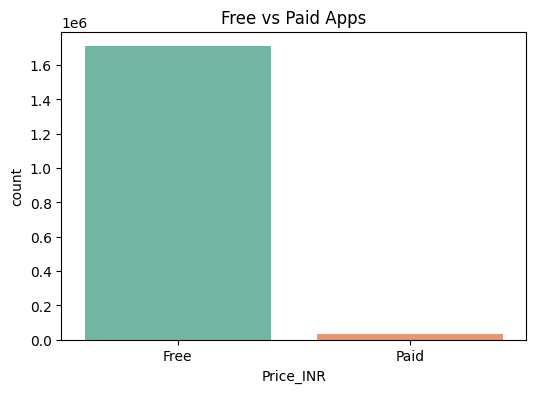

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['Price_INR'].apply(lambda x: 'Paid' if x > 0 else 'Free'), palette='Set2')
plt.title('Free vs Paid Apps')
plt.show()


# Most Popular Content Rating by Installs : barplot

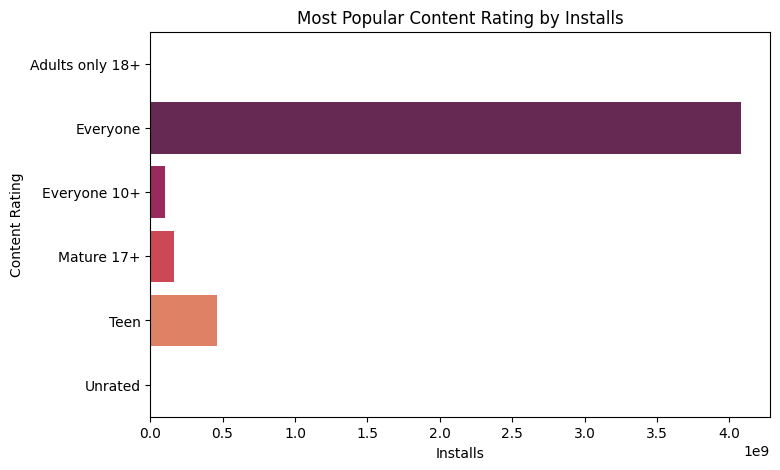

In [ ]:
content_installs = df.groupby('Content Rating')['Installs'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Installs', y='Content Rating', data=content_installs, palette='rocket')
plt.title('Most Popular Content Rating by Installs')
plt.show()


# Installs vs Price (Paid vs Free Apps) scatter plot

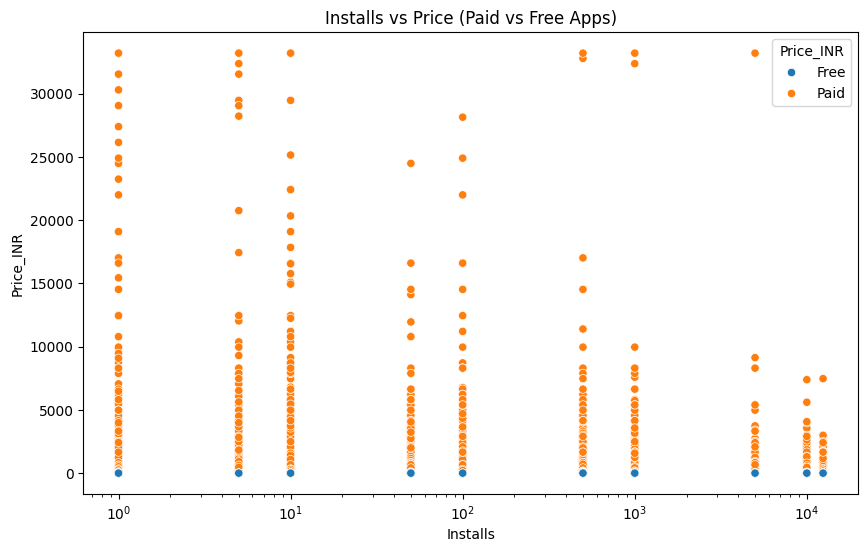

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Installs', y='Price_INR', hue=df['Price_INR'].apply(lambda x: 'Paid' if x > 0 else 'Free')) # Add data=df
plt.title('Installs vs Price (Paid vs Free Apps)')
plt.xscale('log')  # To handle large values in installs
plt.show()


# App Size vs Installs : scatterplot

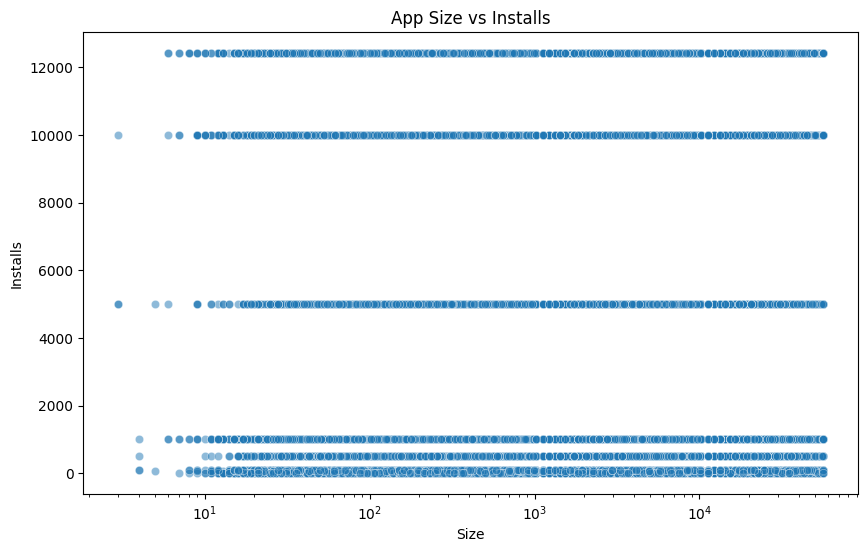

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Size', y='Installs', alpha=0.5)
plt.title('App Size vs Installs')
plt.xscale('log')
plt.show()


# Number of Apps Released per Year : countplot

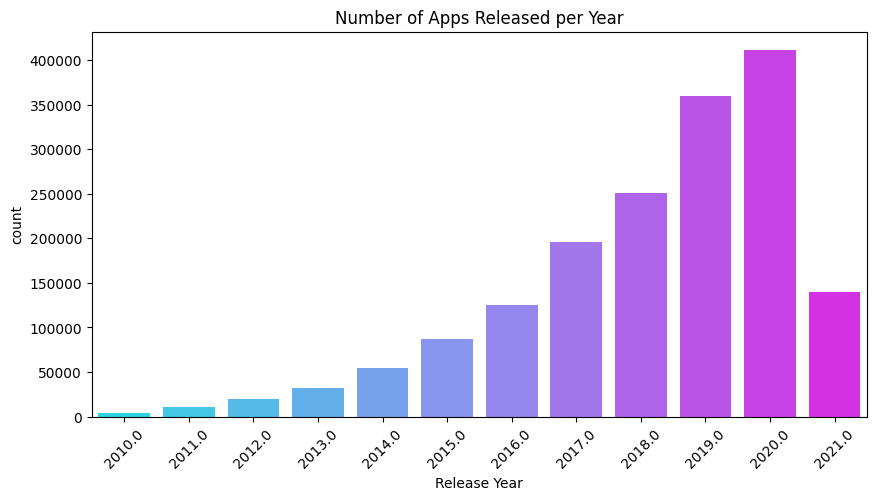

In [ ]:
df['Release Year'] = df['Released'].dt.year
plt.figure(figsize=(10,5))
sns.countplot(x=df['Release Year'], palette='cool')
plt.xticks(rotation=45)
plt.title('Number of Apps Released per Year')
plt.show()


# Apps with In-App Purchases

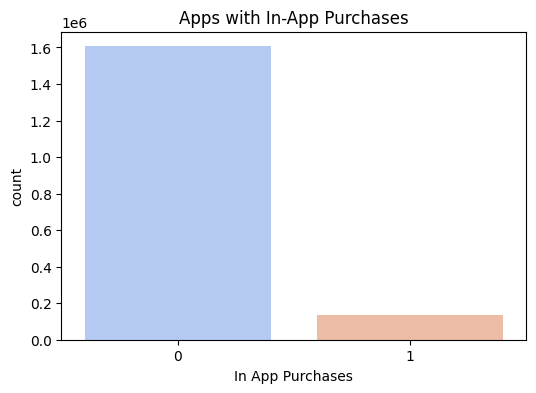

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='In App Purchases', data=df, palette='coolwarm')
plt.title('Apps with In-App Purchases')
plt.show()


# Top 10 Developers with Most Apps

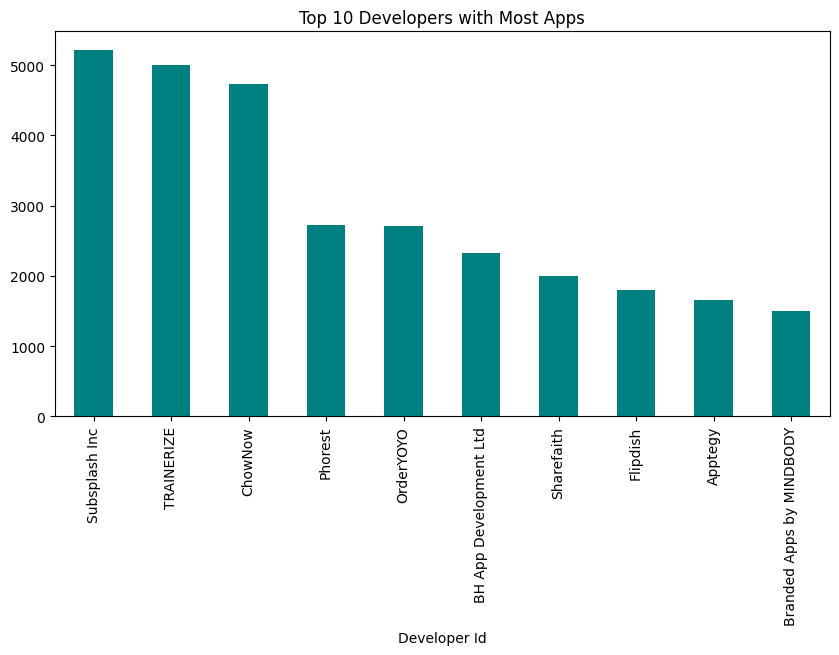

In [ ]:
top_devs = df['Developer Id'].value_counts().nlargest(10)
plt.figure(figsize=(10,5))
top_devs.plot(kind='bar', color='teal')
plt.title('Top 10 Developers with Most Apps')
plt.show()


# Ad-Supported vs Non-Ad Apps

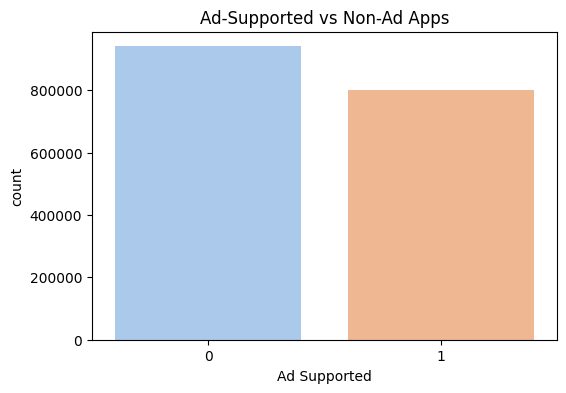

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Ad Supported', data=df, palette='pastel')
plt.title('Ad-Supported vs Non-Ad Apps')
plt.show()


# Top 10 Most Expensive Apps

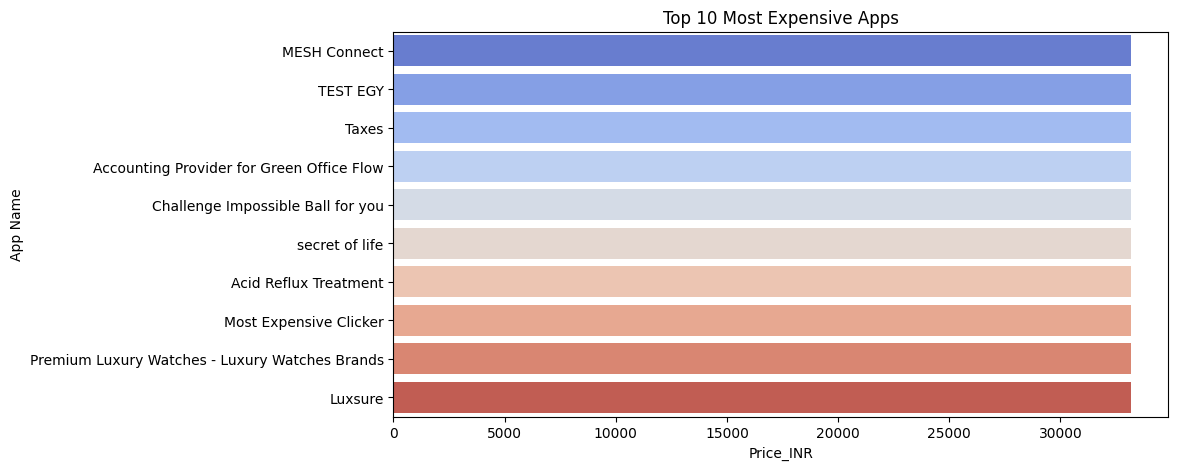

In [ ]:
expensive_apps = df[df['Price_INR'] > 0].nlargest(10, 'Price_INR')
plt.figure(figsize=(10,5))
sns.barplot(x='Price_INR', y='App Name', data=expensive_apps, palette='coolwarm')
plt.title('Top 10 Most Expensive Apps')
plt.show()


In [ ]:
df.to_csv("cleaned_data.csv", index=False)